# Initialization

## Imports

In [1]:
from qutip import *
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display, Latex, Math
# Define custom LaTeX commands
Latex(r"""
\newcommand{\bra}[1]{\left\langle #1 \right|}
\newcommand{\ket}[1]{\left| #1 \right\rangle}
\newcommand{\braket}[2]{\left\langle {#1{\left| \vphantom{#1 #2} \right.} #2} \right\rangle}
""")

<IPython.core.display.Latex object>

## Settings

In [2]:
# Set display width (set a high number to ensure it doesn't wrap)
pd.set_option('display.width', 200)

# Set the maximum number of columns to display
pd.set_option('display.max_columns', 8)

class BraKetDataFrame(pd.DataFrame):
    def __repr__(self):
        temp = self.copy()
        temp.index = [f'|{i}>' for i in temp.index]
        temp.columns = [f'<{j}|' for j in temp.columns]
        return pd.DataFrame.__repr__(temp)

## Functions

In [140]:
def is_prime(n):
  if n == 2 or n == 3: return True
  if n < 2 or n%2 == 0: return False
  if n < 9: return True
  if n%3 == 0: return False
  r = int(n**0.5)
  f = 5
  while f <= r:
    print('\t',f)
    if n % f == 0: return False
    if n % (f+2) == 0: return False
    f += 6
  return True 

#For displaying matrices nicely
def chop(expr, delta=10**-10):
    return np.ma.masked_inside(expr, -delta, delta).filled(0)

def Logical(d=4,j=0):
    if j<0 or j>d-1:
        raise ValueError("check values for which j is defined. 0<=j<d")
    else:
     return Qobj([1 if l==j else 0 for l in range(d)])
    
def LogicalBasis(d=3):
    return [Logical(d,j) for j in range(d)]

#Arbitrary ANG mode in dimension d
def ANG(d=4,state=0):
    return Qobj([1/np.sqrt(d)*np.exp(1j*(2*np.pi/d)*i*state) for i in range(d)])

def ANGBasis(d=4):
    return [ANG(d,state) for state in range(d)]

#Arbitrary MUB mode in dimension d
def MUB(d=4,basis=0,state=0):
    if d==2:
        p=[[[0,0],[0,np.pi]],[[0,np.pi/2],[0,3*np.pi/2]]][basis][state]
        return Qobj([1/np.sqrt(d)*np.exp(1j*phase) for phase in p])
    elif d==4:
        p=[[[0,0,0,0],[0,np.pi,np.pi,0],[0,0,np.pi,np.pi],[0,np.pi,0,np.pi]],[[0,np.pi/2,np.pi/2,np.pi],[0,3*np.pi/2,3*np.pi/2,np.pi],[0,np.pi/2,3*np.pi/2,0],[0,3*np.pi/2,np.pi/2,0]],[[0,0,3*np.pi/2,np.pi/2],[0,np.pi,np.pi/2,np.pi/2],[0,0,np.pi/2,3*np.pi/2],[0,np.pi,3*np.pi/2,3*np.pi/2]],[[0,3*np.pi/2,0,np.pi/2],[0,np.pi/2,np.pi,np.pi/2],[0,np.pi/2,0,3*np.pi/2],[0,3*np.pi/2,np.pi,3*np.pi/2]]][basis][state]
        return Qobj([1/np.sqrt(d)*np.exp(1j*phase) for phase in p])
    elif d==8:
        p=[[[0,0,0,0,0,0,0,0],[0,np.pi/2,np.pi/2,np.pi,np.pi/2,np.pi,np.pi,3*np.pi/2],[0,np.pi/2,0,np.pi/2,0,3*np.pi/2,np.pi,np.pi/2],[0,0,np.pi/2,np.pi/2,np.pi/2,3*np.pi/2,0,np.pi],[0,0,np.pi/2,3*np.pi/2,0,np.pi,np.pi/2,np.pi/2],[0,np.pi/2,0,3*np.pi/2,np.pi/2,0,np.pi/2,np.pi],[0,np.pi/2,np.pi/2,0,0,np.pi/2,3*np.pi/2,np.pi],[0,0,0,np.pi,np.pi/2,np.pi/2,3*np.pi/2,np.pi/2]],[[0,np.pi,0,np.pi,0,np.pi,0,np.pi],[0,3*np.pi/2,np.pi/2,0,np.pi/2,0,np.pi,np.pi/2],[0,3*np.pi/2,0,3*np.pi/2,0,np.pi/2,np.pi,3*np.pi/2],[0,np.pi,np.pi/2,3*np.pi/2,np.pi/2,np.pi/2,0,0],[0,np.pi,np.pi/2,np.pi/2,0,0,np.pi/2,3*np.pi/2],[0,3*np.pi/2,0,np.pi/2,np.pi/2,np.pi,np.pi/2,0],[0,3*np.pi/2,np.pi/2,np.pi,0,3*np.pi/2,3*np.pi/2,0],[0,np.pi,0,0,np.pi/2,3*np.pi/2,3*np.pi/2,3*np.pi/2]],[[0,0,np.pi,np.pi,0,0,np.pi,np.pi],[0,np.pi/2,3*np.pi/2,0,np.pi/2,np.pi,0,np.pi/2],[0,np.pi/2,np.pi,3*np.pi/2,0,3*np.pi/2,0,3*np.pi/2],[0,0,3*np.pi/2,3*np.pi/2,np.pi/2,3*np.pi/2,np.pi,0],[0,0,3*np.pi/2,np.pi/2,0,np.pi,3*np.pi/2,3*np.pi/2],[0,np.pi/2,np.pi,np.pi/2,np.pi/2,0,3*np.pi/2,0],[0,np.pi/2,3*np.pi/2,np.pi,0,np.pi/2,np.pi/2,0],[0,0,np.pi,0,np.pi/2,np.pi/2,np.pi/2,3*np.pi/2]],[[0,np.pi,np.pi,0,0,np.pi,np.pi,0],[0,3*np.pi/2,3*np.pi/2,np.pi,np.pi/2,0,0,3*np.pi/2],[0,3*np.pi/2,np.pi,np.pi/2,0,np.pi/2,0,np.pi/2],[0,np.pi,3*np.pi/2,np.pi/2,np.pi/2,np.pi/2,np.pi,np.pi],[0,np.pi,3*np.pi/2,3*np.pi/2,0,0,3*np.pi/2,np.pi/2],[0,3*np.pi/2,np.pi,3*np.pi/2,np.pi/2,np.pi,3*np.pi/2,np.pi],[0,3*np.pi/2,3*np.pi/2,0,0,3*np.pi/2,np.pi/2,np.pi],[0,np.pi,np.pi,np.pi,np.pi/2,3*np.pi/2,np.pi/2,np.pi/2]],[[0,0,0,0,np.pi,np.pi,np.pi,np.pi],[0,np.pi/2,np.pi/2,np.pi,3*np.pi/2,0,0,np.pi/2],[0,np.pi/2,0,np.pi/2,np.pi,np.pi/2,0,3*np.pi/2],[0,0,np.pi/2,np.pi/2,3*np.pi/2,np.pi/2,np.pi,0],[0,0,np.pi/2,3*np.pi/2,np.pi,0,3*np.pi/2,3*np.pi/2],[0,np.pi/2,0,3*np.pi/2,3*np.pi/2,np.pi,3*np.pi/2,0],[0,np.pi/2,np.pi/2,0,np.pi,3*np.pi/2,np.pi/2,0],[0,0,0,np.pi,3*np.pi/2,3*np.pi/2,np.pi/2,3*np.pi/2]],[[0,np.pi,0,np.pi,np.pi,0,np.pi,0],[0,3*np.pi/2,np.pi/2,0,3*np.pi/2,np.pi,0,3*np.pi/2],[0,3*np.pi/2,0,3*np.pi/2,np.pi,3*np.pi/2,0,np.pi/2],[0,np.pi,np.pi/2,3*np.pi/2,3*np.pi/2,3*np.pi/2,np.pi,np.pi],[0,np.pi,np.pi/2,np.pi/2,np.pi,np.pi,3*np.pi/2,np.pi/2],[0,3*np.pi/2,0,np.pi/2,3*np.pi/2,0,3*np.pi/2,np.pi],[0,3*np.pi/2,np.pi/2,np.pi,np.pi,np.pi/2,np.pi/2,np.pi],[0,np.pi,0,0,3*np.pi/2,np.pi/2,np.pi/2,np.pi/2]],[[0,0,np.pi,np.pi,np.pi,np.pi,0,0],[0,np.pi/2,3*np.pi/2,0,3*np.pi/2,0,np.pi,3*np.pi/2],[0,np.pi/2,np.pi,3*np.pi/2,np.pi,np.pi/2,np.pi,np.pi/2],[0,0,3*np.pi/2,3*np.pi/2,3*np.pi/2,np.pi/2,0,np.pi],[0,0,3*np.pi/2,np.pi/2,np.pi,0,np.pi/2,np.pi/2],[0,np.pi/2,np.pi,np.pi/2,3*np.pi/2,np.pi,np.pi/2,np.pi],[0,np.pi/2,3*np.pi/2,np.pi,np.pi,3*np.pi/2,3*np.pi/2,np.pi],[0,0,np.pi,0,3*np.pi/2,3*np.pi/2,3*np.pi/2,np.pi/2]],[[0,np.pi,np.pi,0,np.pi,0,0,np.pi],[0,3*np.pi/2,3*np.pi/2,np.pi,3*np.pi/2,np.pi,np.pi,np.pi/2],[0,3*np.pi/2,np.pi,np.pi/2,np.pi,3*np.pi/2,np.pi,3*np.pi/2],[0,np.pi,3*np.pi/2,np.pi/2,3*np.pi/2,3*np.pi/2,0,0],[0,np.pi,3*np.pi/2,3*np.pi/2,np.pi,np.pi,np.pi/2,3*np.pi/2],[0,3*np.pi/2,np.pi,3*np.pi/2,3*np.pi/2,0,np.pi/2,0],[0,3*np.pi/2,3*np.pi/2,0,np.pi,np.pi/2,3*np.pi/2,0],[0,np.pi,np.pi,np.pi,3*np.pi/2,np.pi/2,3*np.pi/2,3*np.pi/2]]][state][basis]
        return Qobj([1/np.sqrt(d)*np.exp(1j*phase) for phase in p])

    elif not is_prime(d):
       raise ValueError("This function is for prime numbers only")
    elif d>23:
       raise ValueError("lets keep the dimension small for now d>23")
    else: return Qobj([1/np.sqrt(d)*np.exp(2* np.pi*1j/d * (basis*l**2+state*l)) for l in range(d)])

#All MUBS in a basis
def MUBbasis(d=4,basis=0):
    return [MUB(d,basis,state=l) for l in range(d)]

#All MUBS in a basis
def MUBall(d=4):
    return [MUB(d,basis=b,state=l) for b in range(d) for l in range(d)]

def PUB(d=4,j=0,m=0):
    if d%2!=0:
      raise ValueError("d must be even")
    elif j<0 or j>d//2 or m<0 or m>1:
      raise ValueError("check values for which j,m are defined. 0<=j<d, 0<=m<1")
    else:
        return Qobj([1/np.sqrt(2) if l==2*j or (m==0 and l==2*j+1) else -1/np.sqrt(2) if m==1 and (l==2*j+1) else 0 for l in range(d)])
   
def PUBBasis(d=4):
    return [PUB(d,j,m) for j in range(d//2) for m in range(2)]

def PUBPhase(d=4,j=0,m=0):
    if d%2!=0:
      raise ValueError("d must be even")
    elif j<0 or j>d//2 or m<0 or m>d-1:
      raise ValueError("check values for which j,m are defined. 0<=j<d, 0<=m<1")
    else:
        return Qobj([1/np.sqrt(2) if l==2*j else 1/np.sqrt(2)*np.exp(m*2* np.pi*1j/d) if l==2*j+1 else 0 for l in range(d)])
    
def PUBPhaseBasis(d=4):
    return [PUBPhase(d,j,m) for j in range(d//2) for m in range(d)]

def NNpm(d=4,j=0,m=0):
    if j<0 or j>d-2 or m<0 or m>1:
      raise ValueError("check values for which j,m are defined. 0<=j<d, 0<=m<1")
    else:
        return Qobj([1/np.sqrt(2) if l==j or (m==0 and l==j+1) else -1/np.sqrt(2) if m==1 and (l==j+1) else 0 for l in range(d)])
    
def NNpmBasis(d=4):
    return [NNpm(d,j,m) for j in range(d-1) for m in range(2)]

def NN(d=4,j=0,m=0):
    if j<0 or j>d-2 or m<0 or m>d-1:
      raise ValueError("check values for which j,m are defined. 0<=j<d, 0<=m<1")
    else:
        return Qobj([1/np.sqrt(2) if l==j else 1/np.sqrt(2)*np.exp(m*2* np.pi*1j/d) if l==j+1 else 0 for l in range(d)])

def NNBasis(d=4):
    return [NN(d,j,m) for j in range(d-1) for m in range(d)]

def Fqubitpm(d=4,j=0,k=1,m=0):
   if j>=k or j<0 or d-2<j or k<1 or k>d-1 or 1<m or m<0:
      raise ValueError("check values for which j,k,m are defined. 0<=j<d-2, 1<=k<=d-1, j<k, 0<=m<1")
   else:
    return Qobj([1/np.sqrt(2) if l==j else 1/np.sqrt(2)*np.exp(m*2* np.pi*1j/d) if l==k else 0 for l in range(d)])

def FqubitpmBasis(d=4):
    return [Fqubitpm(d,j,k,m) for j in range(d-1) for k in range(j+1,d) for m in range(2)]

#Arbitrary FQubit mode in dimension d
def Fqubit(d=4,j=0,k=1,m=0):
   if j>=k or j<0 or d-2<j or k<1 or k>d-1 or d-1<m or m<0:
      raise ValueError("check values for which j,k,m are defined. 0<=j<d-2, 1<=k<=d-1, j<k, 0<=m<d")
   else:
    return Qobj([1/np.sqrt(2) if l==j else 1/np.sqrt(2)*np.exp(m*2* np.pi*1j/d) if l==k else 0 for l in range(d)])
   
def Fqubitbasis(d=3):
    return [Fqubit(d,j,k,m) for j in range(d-1) for k in range(j+1,d) for m in range(d)]



def omega(d,number):
   return np.exp(number * 1j * 2 *np.pi/d)

def heatmap(cross,title='Crosstalk'):
    # Set the black background and Times New Roman font
    plt.style.use('default')  # Reset to default style
    plt.rcParams.update({
        'figure.facecolor': '#151515',  # Black background
        'axes.facecolor': '#151515',   # Black axes background
        'text.color': 'white',       # White text
        'axes.labelcolor': 'white',  # White axis labels
        'xtick.color': 'white',      # White x-tick labels
        'ytick.color': 'white',      # White y-tick labels
        'font.size': 18,             # Larger font size
        'font.family': 'serif',      # Use serif fonts
        'font.serif': ['Times New Roman']  # Set Times New Roman
    })

    # Plot the heatmap
    fig, ax = plt.subplots()
    ax.axis('off')  # Turn off axes
    ax.set_title(title,color='white', fontsize=24, pad=20)
    img = ax.imshow(cross, interpolation='none', cmap='viridis', vmin=0, vmax=1)
    cbar = plt.colorbar(img, ax=ax, label='Intensity')  # Add a color bar with a label
    cbar.ax.yaxis.set_tick_params(color='white')  # White ticks on the color bar
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')  # White tick labels on the color bar

    # Adjust layout to minimize borders
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    plt.show()

def heatmap_side_by_side(cross1, cross2, title1="Heatmap 1", title2="Heatmap 2"):
    # Set the darker grey background and Times New Roman font
    plt.style.use('default')  # Reset to default style
    plt.rcParams.update({
        'figure.facecolor': '#151515',  # Black background
        'axes.facecolor': '#151515',   # Black axes background
        'text.color': 'white',         # White text
        'axes.labelcolor': 'white',    # White axis labels
        'xtick.color': 'white',        # White x-tick labels
        'ytick.color': 'white',        # White y-tick labels
        'font.size': 14,               # Larger font size
        'font.family': 'serif',        # Use serif fonts
        'font.serif': ['Times New Roman']  # Set Times New Roman
    })

    # Create subplots for side-by-side heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

    # Plot the first heatmap
    img1 = axes[0].imshow(cross1, interpolation='none', cmap='viridis', vmin=0, vmax=1)
    axes[0].set_title(title1, color='white', fontsize=16, pad=20)
    axes[0].axis('off')  # Turn off axes
    cbar1 = plt.colorbar(img1, ax=axes[0], label='Intensity')
    cbar1.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar1.ax.axes, 'yticklabels'), color='white')

    # Plot the second heatmap
    img2 = axes[1].imshow(cross2, interpolation='none', cmap='viridis', vmin=0, vmax=1)
    axes[1].set_title(title2, color='white', fontsize=16, pad=20)
    axes[1].axis('off')  # Turn off axes
    cbar2 = plt.colorbar(img2, ax=axes[1], label='Intensity')
    cbar2.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar2.ax.axes, 'yticklabels'), color='white')

    # Adjust layout to minimize borders
    plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.3)

    plt.show()

def norm_cross(cross):
    # Normalize every d elements in a row
    d = len(cross) // 2  # Assuming input is always 2*d
    normalized_cross = np.array([
        [row[i * d:(i + 1) * d] / np.sum(row[i * d:(i + 1) * d]) if np.sum(row[i * d:(i + 1) * d]) != 0 else row[i * d:(i + 1) * d] for i in range(2)]
        for row in cross
    ])    
    # Flatten the normalized chunks back into the original row structure
    normalized_cross = np.array([np.concatenate(row_chunks) for row_chunks in normalized_cross])

    return normalized_cross

# Create Bases

## Create MUB crosstalks

Number of states: 8


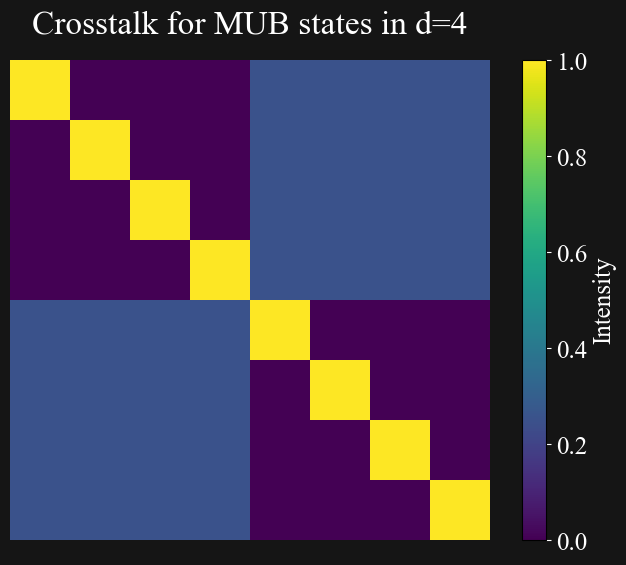

In [162]:
d=4
basis=LogicalBasis(d)+ANGBasis(d)
print(f'Number of states: {len(basis)}')

heatmap([[abs(state1.dag()*state2)**2 for state1 in basis] for state2 in basis],f'Crosstalk for MUB states in d={d}')

## Create PUB +- states

Number of states: 8


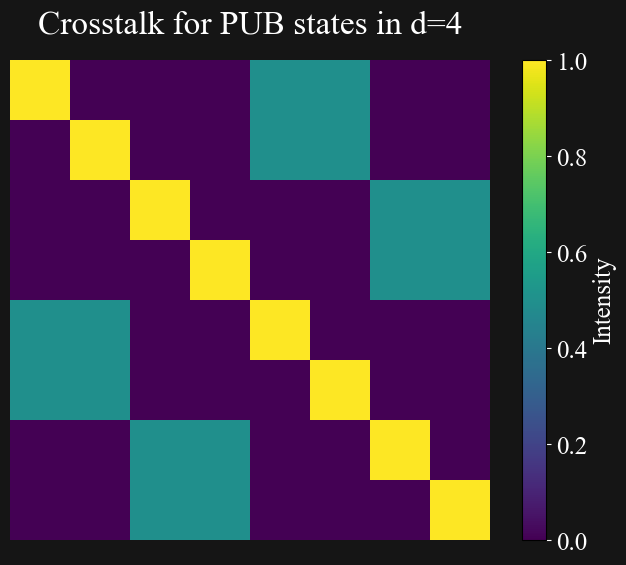

In [163]:
d=4
basis=LogicalBasis(d)+PUBBasis(d)
print(f'Number of states: {len(basis)}')

heatmap([[abs(state1.dag()*state2)**2 for state1 in basis] for state2 in basis],f'Crosstalk for PUB states in d={d}')

## Pub Phase Modes

Number of states: 12


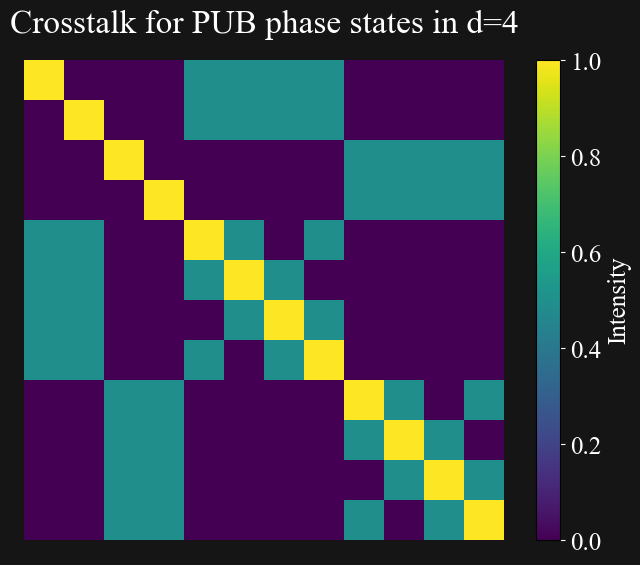

In [164]:
d=4
basis=LogicalBasis(d)+PUBPhaseBasis(d)
print(f'Number of states: {len(basis)}')

heatmap([[abs(state1.dag()*state2)**2 for state1 in basis] for state2 in basis],f'Crosstalk for PUB phase states in d={d}')

## Nearest Neighbour +- modes

Number of states: 10


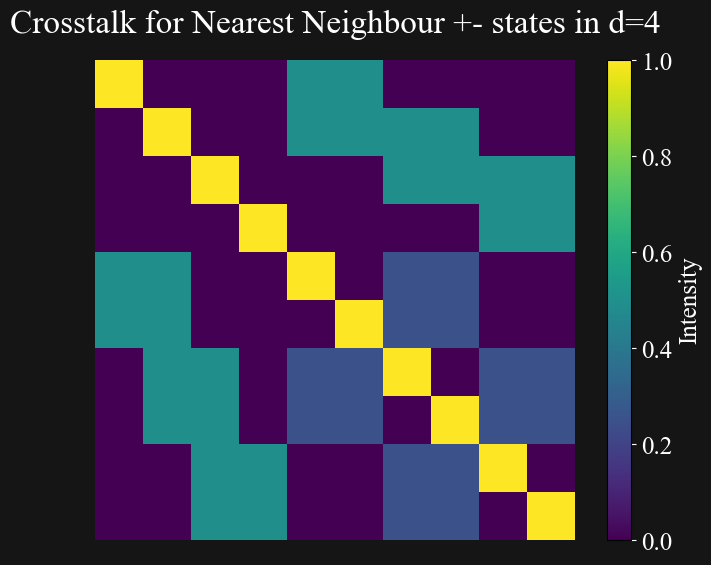

In [165]:
d=4
basis=LogicalBasis(d)+NNpmBasis(d)
print(f'Number of states: {len(basis)}')

heatmap([[abs(state1.dag()*state2)**2 for state1 in basis] for state2 in basis],f'Crosstalk for Nearest Neighbour +- states in d={d}')

## Nearest Neighbour Phase modes

Number of states: 16


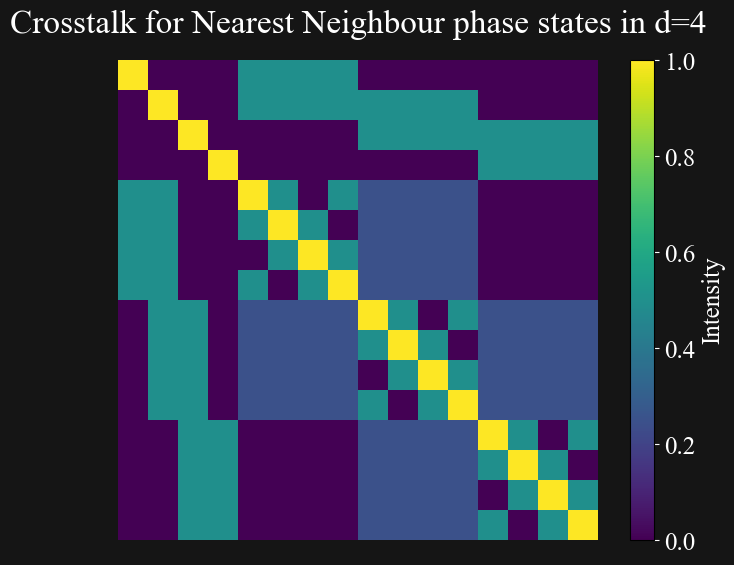

In [166]:
d=4
basis=LogicalBasis(d)+NNBasis(d)
print(f'Number of states: {len(basis)}')

heatmap([[abs(state1.dag()*state2)**2 for state1 in basis] for state2 in basis],f'Crosstalk for Nearest Neighbour phase states in d={d}')

## Create FQB +- crosstalks

Number of states: 16


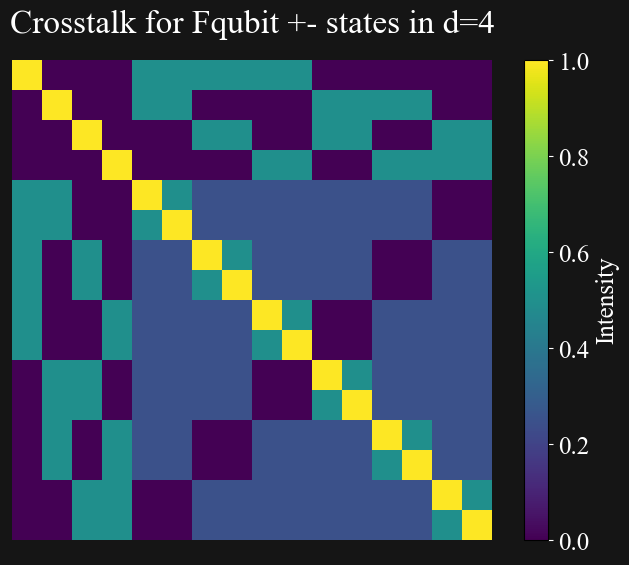

In [169]:
d=4
basis=LogicalBasis(d)+FqubitpmBasis(d)
print(f'Number of states: {len(basis)}')

heatmap([[abs(state1.dag()*state2)**2 for state1 in basis] for state2 in basis],f'Crosstalk for Fqubit +- states in d={d}')

## Create FQB crosstalks

Number of states: 28


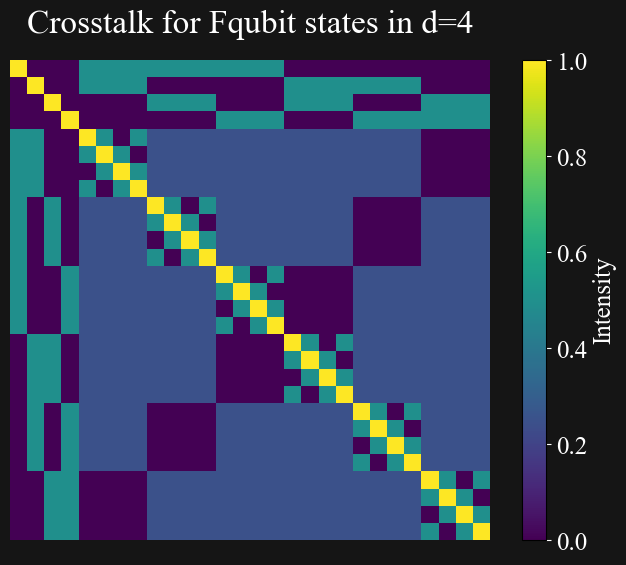

In [170]:
d=4
basis=LogicalBasis(d)+Fqubitbasis(d)
print(f'Number of states: {len(basis)}')

heatmap([[abs(state1.dag()*state2)**2 for state1 in basis] for state2 in basis],f'Crosstalk for Fqubit states in d={d}')

# Make FQubit state from any MUB

In [7]:
# Only works for prime dimensions
d=5
j,k,m,r=0,1,0,1

1/np.sqrt(2*d)*sum([(omega(d,-r*j**2-l*j)+omega(d,m-r*k**2-l*k))*state for l,state in enumerate(MUBbasis(d,r))])

Quantum object: dims=[[5], [1]], shape=(5, 1), type='ket', dtype=Dense
Qobj data =
[[ 7.07106781e-01]
 [ 7.07106781e-01]
 [ 3.51083347e-17]
 [ 8.77708367e-17]
 [-3.51083347e-17]]

## Find Probabilities of FQB and ANG  given the other

### Find MUB probabilities given FQB probabilities

In [36]:
d=3
op = rand_unitary(d)
op= identity(d)

In [37]:
display(Latex(r"Random unitary operator ($U$):"))
print(pd.DataFrame(chop(op.full())))


display(Latex(r"Proof of unitarity: Random unitary operator left and/or right multiplied by its conjugate ($U^{\dagger} U=U U^{\dagger}$):"))
print(BraKetDataFrame(pd.DataFrame(chop((op.dag() * op).full()))))
print(BraKetDataFrame(pd.DataFrame(chop((op * op.dag()).full()))))

<IPython.core.display.Latex object>

          0         1         2
0  1.0+0.0j  0.0+0.0j  0.0+0.0j
1  0.0+0.0j  1.0+0.0j  0.0+0.0j
2  0.0+0.0j  0.0+0.0j  1.0+0.0j


<IPython.core.display.Latex object>

          <0|       <1|       <2|
|0>  1.0+0.0j  0.0+0.0j  0.0+0.0j
|1>  0.0+0.0j  1.0+0.0j  0.0+0.0j
|2>  0.0+0.0j  0.0+0.0j  1.0+0.0j
          <0|       <1|       <2|
|0>  1.0+0.0j  0.0+0.0j  0.0+0.0j
|1>  0.0+0.0j  1.0+0.0j  0.0+0.0j
|2>  0.0+0.0j  0.0+0.0j  1.0+0.0j


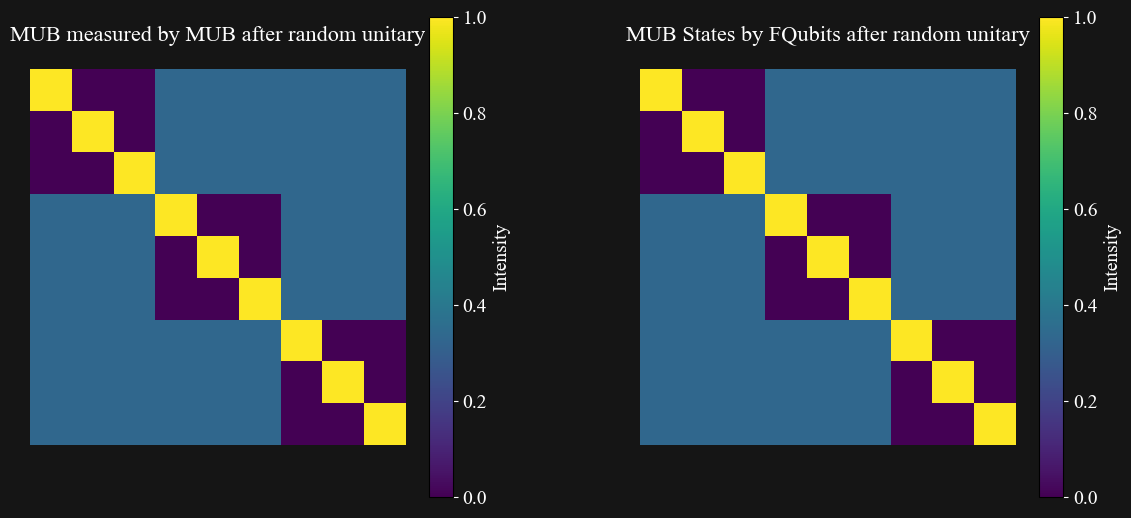

In [38]:
#MUB states projected on MUB states after applying the operator
MUBop=[[abs(state1.dag()*op*state2)**2 for state1 in MUBall(d)] for state2 in MUBall(d)]

#Functions to calculate probability of measuring MUB usin FQubits after applying the operator 
# Try to keep d<6
def term(d,j,k,m,l,r):
    return ((2-d)/(d-1))+sum([np.exp(((2*np.pi*1j/d)*(p*(m-(k-j)*l-(k**2-j**2)*r)))) for p in range(d)])
def msum(d,n,l,r,rp):
    if d==6:
        raise ValueError("do not use d=6")
    else: 
        return abs((4/d**4)*sum([term(d,j,k,m,l,r)*term(d,jp,kp,mp,n,rp)*(abs(Fqubit(d,jp,kp,mp).dag()*op*Fqubit(d,j,k,m))**2) for j in range(d-1) for k in range(j+1,d) for jp in range(d-1) for kp in range(jp+1,d) for m in range(d) for mp in range(d)]))
#FQubit states projected on FQubit states after applying the operator transformed into the MUB Basis
FQBop=[[msum(d,n,l,r,rp) for rp in range(d) for n in range(d) ] for r in range(d) for l in range(d)]

heatmap_side_by_side(MUBop,FQBop,'MUB measured by MUB after random unitary','MUB States by FQubits after random unitary')

In [11]:
MUB(d,0,1)

Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.57735027+0.j ]
 [-0.28867513+0.5j]
 [-0.28867513-0.5j]]

In [12]:
Fqubit(d,0,1,0)

Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]
 [0.        ]]

#### Displaying MUB state measurements

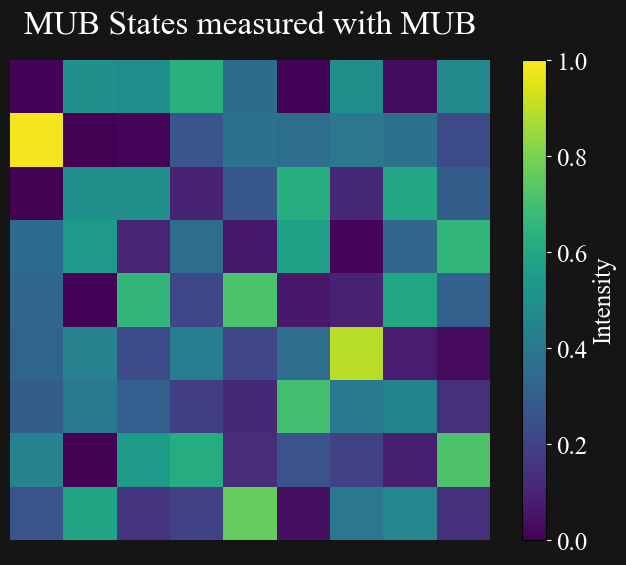

In [13]:
#MUB states projected on MUB states after applying the operator
heatmap([[abs(state1.dag()*op*state2)**2 for state1 in MUBall(d)] for state2 in MUBall(d)],'MUB States measured with MUB')


#### Reconstructing MUBs from FQubits

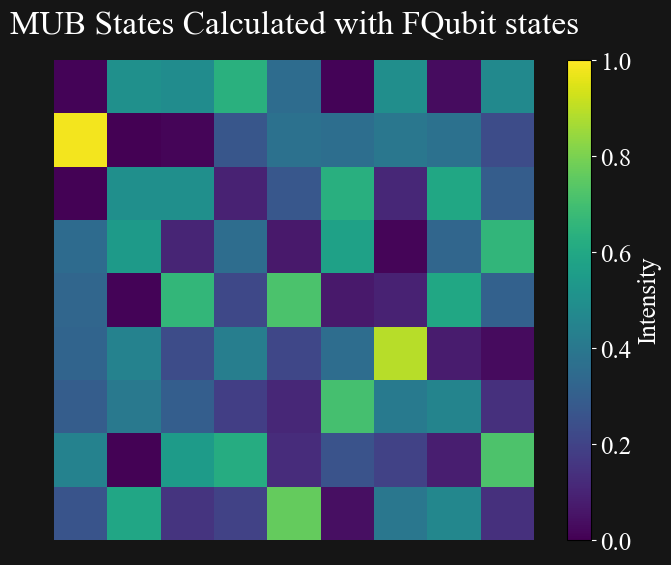

In [14]:
# Try to keep d<6
def term(d,j,k,m,l,r):
    return ((2-d)/(d-1))+sum([np.exp(((2*np.pi*1j/d)*(p*(m-(k-j)*l-(k**2-j**2)*r)))) for p in range(d)])

def msum(d,n,l,r,rp):
    if d==6:
        raise ValueError("do not use d=6")
    else: 
        return abs((4/d**4)*sum([term(d,j,k,m,l,r)*term(d,jp,kp,mp,n,rp)*(abs(Fqubit(d,jp,kp,mp).dag()*op*Fqubit(d,j,k,m))**2) for j in range(d-1) for k in range(j+1,d) for jp in range(d-1) for kp in range(jp+1,d) for m in range(d) for mp in range(d)]))


heatmap([[msum(d,n,l,r,rp) for rp in range(d) for n in range(d) ] for r in range(d) for l in range(d)],'MUB States Calculated with FQubit states')

### Find FQB given ANG

In [15]:
d=5

def probFQB(jp,kp,mp,j,k,m):
    return (4/d**2)*sum([(np.cos(np.pi*(m-(k-j)*l)/d)**2)*(np.cos(np.pi*(mp-(kp-jp)*n)/d)**2)*(abs(MUB(d,0,n).dag()*MUB(d,0,l))**2) for n in range(d) for l in range(d)])

probFQB(0,1,0,0,1,0)

np.float64(0.29999999999999993)

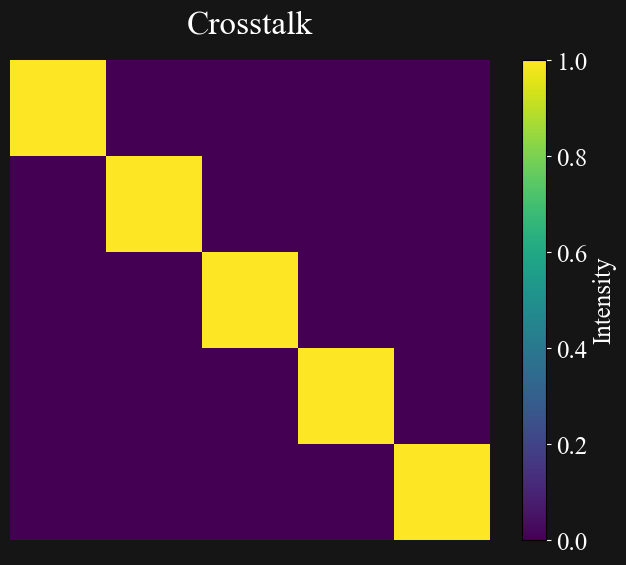

In [16]:
heatmap([[(abs(MUB(d,0,n).dag()*MUB(d,0,l))**2) for n in range(d)] for l in range(d)])

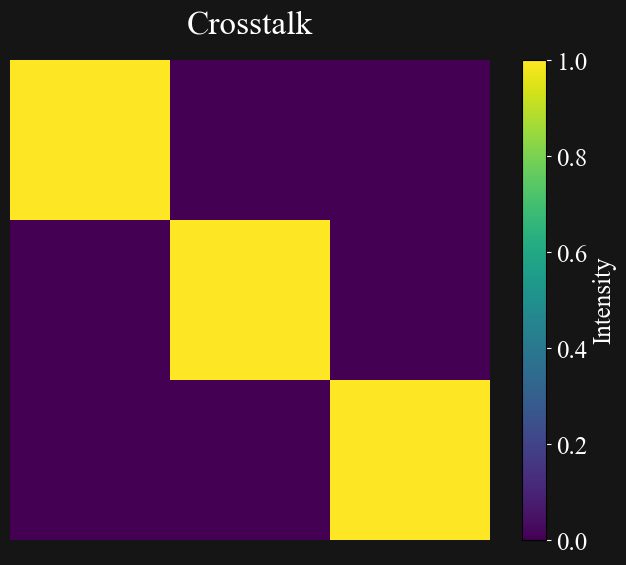

In [17]:
# Try to keep d<6
d=3

def term(d,j,k,m,l):
    return ((2-d)/(d-1))+sum([np.exp(((2*np.pi*1j/d)*(p*(m-(k-j)*l)))) for p in range(d)])

def msum(d,n,l):
    if d==6:
        raise ValueError("do not use d=6")
    else: 
        return abs((4/d**4)*sum([term(d,j,k,m,l)*term(d,jp,kp,mp,n)*(abs(Fqubit(d,jp,kp,mp).dag()*Fqubit(d,j,k,m))**2) for j in range(d-1) for k in range(j+1,d) for jp in range(d-1) for kp in range(jp+1,d) for m in range(d) for mp in range(d)]))


heatmap([[msum(d,n,l) for n in range(d)] for l in range(d)])

## 3D F-Qubits are SICPOVMs!

<IPython.core.display.Latex object>

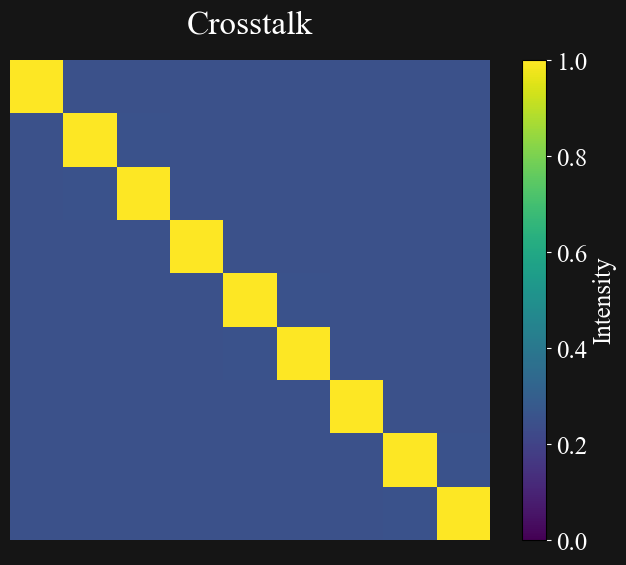

In [18]:
d=3
display(Latex(r"$| \braket{\psi_{\alpha}|\psi_{\beta}}|^2=1/d \:\:\: \forall \:\:\: \alpha \neq \beta $"))
heatmap([[abs(Fqubit(d,j,k,m).dag()*Fqubit(d,jp,kp,mp))**2 for j in range(d-1) for k in range(j+1,d) for m in range(d)] for jp in range(d-1) for kp in range(jp+1,d) for mp in range(d)])

# Full Tomography

In [19]:
d = 5
FQBs = Fqubitbasis(d)

# 2. Rho is unknown state 
rho = rand_ket(d).proj()    # Random Pure state
#rho = rand_dm(d)            # Random mixed state

print(BraKetDataFrame(pd.DataFrame(rho.full())))

# 3. Measure probabilities for each F-Qubit
probs = [np.real((fq.dag() * rho * fq)) for fq in FQBs]

# 4. Reconstruct the state (linear inversion example)
# Build the measurement matrix
M = np.array([fq.full().flatten() for fq in FQBs])
# Solve for the state vector (for pure states)
from numpy.linalg import lstsq
state_vec, _, _, _ = lstsq(M, np.array(probs), rcond=None)

# Build the measurement operators
P = [fq * fq.dag() for fq in FQBs]

# Build the system: p_i = Tr(rho P_i)
# Flatten rho into a vector (for d=3, 9 elements)
from qutip import Qobj
A = np.array([P_i.full().flatten() for P_i in P])
b = np.array(probs)

# Solve for rho_flat using least squares
rho_flat, _, _, _ = lstsq(A, b, rcond=None)
rho_rec = Qobj(rho_flat.reshape((d, d)))

print("Reconstructed density matrix:")
print(BraKetDataFrame(pd.DataFrame(rho_rec.full().conj())))

                    <0|                 <1|                 <2|                 <3|                 <4|
|0>  0.278511+0.000000j  0.059475-0.101458j -0.241134-0.208785j -0.167598-0.122506j  0.036643-0.202323j
|1>  0.059475+0.101458j  0.049661+0.000000j  0.024565-0.132428j  0.008838-0.087215j  0.081529-0.029857j
|2> -0.241134+0.208785j  0.024565+0.132428j  0.365289+0.000000j  0.236943-0.019574j  0.119946+0.202641j
|3> -0.167598+0.122506j  0.008838+0.087215j  0.236943+0.019574j  0.154741+0.000000j  0.066944+0.137869j
|4>  0.036643+0.202323j  0.081529+0.029857j  0.119946-0.202641j  0.066944-0.137869j  0.151798+0.000000j
Reconstructed density matrix:
                    <0|                 <1|                 <2|                 <3|                 <4|
|0>  0.278511-0.000000j  0.059475-0.101458j -0.241134-0.208785j -0.167598-0.122506j  0.036643-0.202323j
|1>  0.059475+0.101458j  0.049661-0.000000j  0.024565-0.132428j  0.008838-0.087215j  0.081529-0.029857j
|2> -0.241134+0.208785j  0.024565+